<hr style="border:2px solid gray">

# Part 2: Programming assignment 

Exercise 1 includes two problems that you need to solve with programming (+ one extra task which is optional). For each problem you need to modify the notebook by adding your own solutions. Remember to save and commit your changes locally, and push your changes to GitHub after each major change! Regular commits will help you to keep track of your changes (and revert them if needed). Pushing your work to GitHub will ensure that you don't lose any work in case your computer crashes (can happen!).

The purpose of this programming assignment is to familiarize yourself with some basic functionalities of geopandas. 
An overview of the tasks:

 - extract OpenStreetMap data from Helsinki Region
 - make a simple visualization  
 - calculate building density for a given district
 
### Start your exercise in CSC Notebooks

Before you can start programming, you need to launch the CSC Notebook instance and clone your Exercise repository there.
If you need help with this, [read the documentation on the course site](https://sustainability-gis.readthedocs.io/en/latest/lessons/L1/git-basics.html).
 
### Hints 

If there are general questions arising from this exercise, we will add hints to the course website under [Exercise 1 description](https://sustainability-gis.readthedocs.io/en/latest/lessons/L1/exercise-1.html). 


## Problem 1 

Before you start, go through the [Python tutorial 1](https://sustainability-gis.readthedocs.io/en/latest/tutorials/intro-to-python-geostack.html) which should give you all necessary information with examples to complete this exercise. 

In the first task you should write code in which you:
 
 - **Download OSM data for the postal code area where you live using `osmnx`** (or some other area which interests you). You should read the following datasets from the given postal code area:
 
   1. Buildings
   2. Roads
   3. Administrative boundary for the city area 
  
 - **Reproject the datasets to EPSG:3067** (Euref-FIN) 
 - **Visualize** the reprojected buildings, roads and the administrative boundary and produce a map that pleases your eye (style is free). 
   - Add a title to your map
   - If you want to use black background you can `import matplotlib.pyplot as plt` and specify `plt.style.use("dark_background")`
   - For example, the output could look like following:
 
![Ullanlinna](img/hoods-example.png)
   

Please write your solution to the cell below (remove the `raise NotImplementedError()` code). You can create new cells as well if needed.

In [31]:
# First we gonna install 
#STEP 1: Install required Python libraries
# These libraries are needed to download, process, and plot
# spatial data from OpenStreetMap.
!pip install osmnx geopandas matplotlib




In [6]:
# STEP 2: Import the required libraries
# osmnx     -> download roads, buildings, and boundaries
# geopandas -> handle spatial (GIS) data
# matplotlib-> create maps and plots

import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt

print("osmnx version:", ox.__version__)
print("geopandas version:", gpd.__version__)

osmnx version: 2.0.1
geopandas version: 1.0.1


In [7]:
# STEP 3: Check library versions
# This helps to make sure the correct versions are being used.
ox.settings.use_cache = True
ox.settings.log_console = False

print("Cache:", ox.settings.use_cache)
print("Log console:", ox.settings.log_console)

Cache: True
Log console: False


In [8]:
# STEP 4: Set OSMnx settings
# Cache is turned on to speed up repeated downloads.
# Console logging is turned off to keep output clean.

#postcal code has been defined
POSTAL_CODE = "02150"
PLACE_QUERY = f"{POSTAL_CODE}, Espoo, Finland"
CITY_QUERY  = "Espoo, Finland"

print("POSTAL_CODE:", POSTAL_CODE)
print("PLACE_QUERY:", PLACE_QUERY)
print("CITY_QUERY :", CITY_QUERY)

POSTAL_CODE: 02150
PLACE_QUERY: 02150, Espoo, Finland
CITY_QUERY : Espoo, Finland


In [9]:
# STEP 5: Define the study area
# Postal code 02150 is used as the main study area.
# Espoo city boundary is also downloaded for reference.

postal_area = ox.geocode_to_gdf(PLACE_QUERY)
city_area   = ox.geocode_to_gdf(CITY_QUERY)

print("postal_area rows:", len(postal_area))
print("city_area rows  :", len(city_area))
postal_area.head()

postal_area rows: 1
city_area rows  : 1


,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((24.73947 60.13879, 24.73947 60.22852...",24.77954,60.133658,24.879541,60.233658,350439636,60.183658,24.829541,place,postcode,21,0.12001,postcode,02150,"02150, Otaniemi, Suur-Tapiola, Espoo, Helsinki..."


In [10]:
# STEP 6: Download boundary polygons from OpenStreetMap
# This gives the geographic boundaries for the postal area
# and the whole city of Espoo.
print("Postal geometry type:", postal_area.geometry.iloc[0].geom_type)
print("City geometry type  :", city_area.geometry.iloc[0].geom_type)

postal_poly = postal_area.geometry.iloc[0]
print("Postal polygon area (degrees CRS):", postal_poly.area)

Postal geometry type: Polygon
City geometry type  : Polygon
Postal polygon area (degrees CRS): 0.016164425812660706


In [11]:
# STEP 7: Check geometry type of downloaded areas
# The boundary should be a polygon.
buildings = ox.features_from_polygon(postal_poly, tags={"building": True})

print("Total buildings features:", len(buildings))
print("Geometry types in buildings:\n", buildings.geometry.type.value_counts())
buildings.head()

Total buildings features: 22907
Geometry types in buildings:
 Polygon         22866
Point              34
MultiPolygon        7
Name: count, dtype: int64


geometry addr:city addr:housenumber  \
element id                                                                 
node    281571338     POINT (24.9145 60.1755)  Helsinki                1   
        288148292   POINT (24.81865 60.20851)       NaN              NaN   
        408451220   POINT (24.87833 60.14622)       NaN              NaN   
        886010759   POINT (24.76407 60.18555)       NaN              NaN   
        5626943261  POINT (24.79724 60.17161)       NaN              NaN   

                   addr:postcode      addr:street    amenity   building  \
element id                                                                
node    281571338          00100  Hiekkarannantie  ice_cream      kiosk   
        288148292            NaN              NaN        NaN     bunker   
        408451220            NaN              NaN        NaN     bunker   
        886010759            NaN              NaN        NaN  container   
        5626943261           NaN              NaN        NaN       roof   

                   diet:halal diet:kosher                     name  ...  \
element id                                                          ...   
node    281571338          no          no  Helsingin jäätelötehdas  ...   
        288148292         NaN         NaN                      NaN  ...   
        408451220         NaN         NaN                      NaN  ...   
        886010759         NaN         NaN                      NaN  ...   
        5626943261        NaN         NaN                      NaN  ...   

                   payment:app sauna shelter generator:output:hot_air pump  \
element id                                                                   
node    281571338          NaN   NaN     NaN                      NaN  NaN   
        288148292          NaN   NaN     NaN                      NaN  NaN   
        408451220          NaN   NaN     NaN                      NaN  NaN   
        886010759          NaN   NaN     NaN                      NaN  NaN   
        5626943261         NaN   NaN     NaN                      NaN  NaN   

                   type building:maintenance:operator:official_name  \
element id                                                            
node    281571338   NaN                                         NaN   
        288148292   NaN                                         NaN   
        408451220   NaN                                         NaN   
        886010759   NaN                                         NaN   
        5626943261  NaN                                         NaN   

                   payment:cheque payment:diners_club commercial  
element id                                                        
node    281571338             NaN                 NaN        NaN  
        288148292             NaN                 NaN        NaN  
        408451220             NaN                 NaN        NaN  
        886010759             NaN                 NaN        NaN  
        5626943261            NaN                 NaN        NaN  

[5 rows x 425 columns]

In [32]:
# STEP 8:# Remove buildings with missing geometry
# This cleans the data so only valid building shapes are kept.

buildings = buildings[buildings.geometry.notna()].copy()
print("After removing null geometries:", len(buildings))

After removing null geometries: 22907


In [33]:
# STEP 9:# Import OSMnx and configure global settings for data download and logging
# Caching is enabled to avoid repeated downloads, console logging is turned on
# for transparency, and the timeout is increased to prevent infinite waiting.

import osmnx as ox
ox.settings.use_cache = True
ox.settings.log_console = True
ox.settings.timeout = 180  # avoid infinite wait


In [34]:
# STEP 10 # Convert the street network graph into GeoDataFrames.
# Nodes represent intersections and endpoints, while edges represent road segments.
# Edge geometries are explicitly created to enable spatial analysis and mapping.

nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True, fill_edge_geometry=True)

print("nodes rows:", len(nodes))
print("edges rows:", len(edges))
edges.head()

nodes rows: 3882
edges rows: 7977


osmid  \
u      v         key                                                      
131941 25156903  0                     [264473404, 179043485, 24787814]   
       134888    0    [172347656, 81178546, 27322644, 4298740, 27322...   
131979 25156911  0    [76737123, 24787912, 301517769, 18467132, 1790...   
       29416840  0                                             85564173   
       877599669 0                                            155797293   

                          highway   lanes  maxspeed              name  oneway  \
u      v         key                                                            
131941 25156903  0      secondary  [1, 2]        40    Kuusisaarentie    True   
       134888    0      secondary       2        50    Kuusisaarentie   False   
131979 25156911  0      secondary       2  [40, 50]    Kuusisaarentie   False   
       29416840  0      secondary       2        50    Kuusisaarentie   False   
       877599669 0    residential       2        30  Kuusisaarenpolku   False   

                     reversed      length  \
u      v         key                        
131941 25156903  0      False   79.452978   
       134888    0       True  650.182260   
131979 25156911  0       True  431.616014   
       29416840  0      False   35.818509   
       877599669 0       True   14.732132   

                                                               geometry  \
u      v         key                                                      
131941 25156903  0    LINESTRING (24.84902 60.18152, 24.84943 60.181...   
       134888    0    LINESTRING (24.84902 60.18152, 24.84631 60.181...   
131979 25156911  0    LINESTRING (24.85721 60.18443, 24.85695 60.184...   
       29416840  0    LINESTRING (24.85721 60.18443, 24.85748 60.184...   
       877599669 0    LINESTRING (24.85721 60.18443, 24.85708 60.184...   

                     bridge  ref junction width tunnel access est_width  
u      v         key                                                     
131941 25156903  0      NaN  NaN      NaN   NaN    NaN    NaN       NaN  
       134888    0      yes  NaN      NaN   NaN    NaN    NaN       NaN  
131979 25156911  0      yes  NaN      NaN   NaN    NaN    NaN       NaN  
       29416840  0      NaN  NaN      NaN   NaN    NaN    NaN       NaN  
       877599669 0      NaN  NaN      NaN   NaN    NaN    NaN       NaN

In [24]:
# STEP 11: Remove buildings with missing geometry
# This cleans the data so only valid building shapes are kept.
buildings = buildings[buildings.geometry.notna()].copy()
print("After removing null geometries:", len(buildings))


After removing null geometries: 22907


In [25]:
# STEP 12: Download the road network inside the postal area
# Only drivable roads are included and the network is simplified.
G = ox.graph_from_polygon(postal_poly, network_type="drive", simplify=True)

print("Graph nodes:", len(G.nodes))
print("Graph edges:", len(G.edges))

Graph nodes: 3882
Graph edges: 7977


In [26]:
# STEP 13# Convert the street network graph into GeoDataFrames.
# Nodes represent intersections and endpoints, and edges represent road segments.
# Edge geometries are created to support spatial analysis and visualization.
nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True, fill_edge_geometry=True)

print("nodes rows:", len(nodes))
print("edges rows:", len(edges))
edges.head()

nodes rows: 3882
edges rows: 7977


osmid  \
u      v         key                                                      
131941 25156903  0                     [264473404, 179043485, 24787814]   
       134888    0    [172347656, 81178546, 27322644, 4298740, 27322...   
131979 25156911  0    [76737123, 24787912, 301517769, 18467132, 1790...   
       29416840  0                                             85564173   
       877599669 0                                            155797293   

                          highway   lanes  maxspeed              name  oneway  \
u      v         key                                                            
131941 25156903  0      secondary  [1, 2]        40    Kuusisaarentie    True   
       134888    0      secondary       2        50    Kuusisaarentie   False   
131979 25156911  0      secondary       2  [40, 50]    Kuusisaarentie   False   
       29416840  0      secondary       2        50    Kuusisaarentie   False   
       877599669 0    residential       2        30  Kuusisaarenpolku   False   

                     reversed      length  \
u      v         key                        
131941 25156903  0      False   79.452978   
       134888    0       True  650.182260   
131979 25156911  0       True  431.616014   
       29416840  0      False   35.818509   
       877599669 0       True   14.732132   

                                                               geometry  \
u      v         key                                                      
131941 25156903  0    LINESTRING (24.84902 60.18152, 24.84943 60.181...   
       134888    0    LINESTRING (24.84902 60.18152, 24.84631 60.181...   
131979 25156911  0    LINESTRING (24.85721 60.18443, 24.85695 60.184...   
       29416840  0    LINESTRING (24.85721 60.18443, 24.85748 60.184...   
       877599669 0    LINESTRING (24.85721 60.18443, 24.85708 60.184...   

                     bridge  ref junction width tunnel access est_width  
u      v         key                                                     
131941 25156903  0      NaN  NaN      NaN   NaN    NaN    NaN       NaN  
       134888    0      yes  NaN      NaN   NaN    NaN    NaN       NaN  
131979 25156911  0      yes  NaN      NaN   NaN    NaN    NaN       NaN  
       29416840  0      NaN  NaN      NaN   NaN    NaN    NaN       NaN  
       877599669 0      NaN  NaN      NaN   NaN    NaN    NaN       NaN

In [27]:
# STEP 14: Select road features from the edges GeoDataFrame
# Only LineString and MultiLineString geometries are kept, as these represent road segments.
roads = edges[edges.geometry.type.isin(["LineString", "MultiLineString"])].copy()
print("roads rows (LineString/MultiLineString):", len(roads))

roads rows (LineString/MultiLineString): 7977


In [28]:
# STEP 15: Reproject all spatial datasets to a common coordinate reference system (EPSG:3067).
# Using a unified CRS ensures that layers align correctly and allows accurate distance,
# area, and spatial analyses.
CRS_FIN = "EPSG:3067"

postal_area_3067 = postal_area.to_crs(CRS_FIN)
city_area_3067   = city_area.to_crs(CRS_FIN)
buildings_3067   = buildings.to_crs(CRS_FIN)
roads_3067       = roads.to_crs(CRS_FIN)

print("CRS postal:", postal_area_3067.crs)
print("CRS city  :", city_area_3067.crs)
print("CRS bldgs :", buildings_3067.crs)
print("CRS roads :", roads_3067.crs)

CRS postal: EPSG:3067
CRS city  : EPSG:3067
CRS bldgs : EPSG:3067
CRS roads : EPSG:3067


In [29]:
# STEP 16: Select only polygon-based building geometries
# Buildings are represented as Polygon or MultiPolygon geometries; other geometry
# types are excluded to ensure correct area-based analysis and visualization.

poly_buildings = buildings_3067[buildings_3067.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()

print("Polygon buildings:", len(poly_buildings))
print("All buildings geom types:\n", buildings_3067.geometry.type.value_counts())

Polygon buildings: 22873
All buildings geom types:
 Polygon         22866
Point              34
MultiPolygon        7
Name: count, dtype: int64


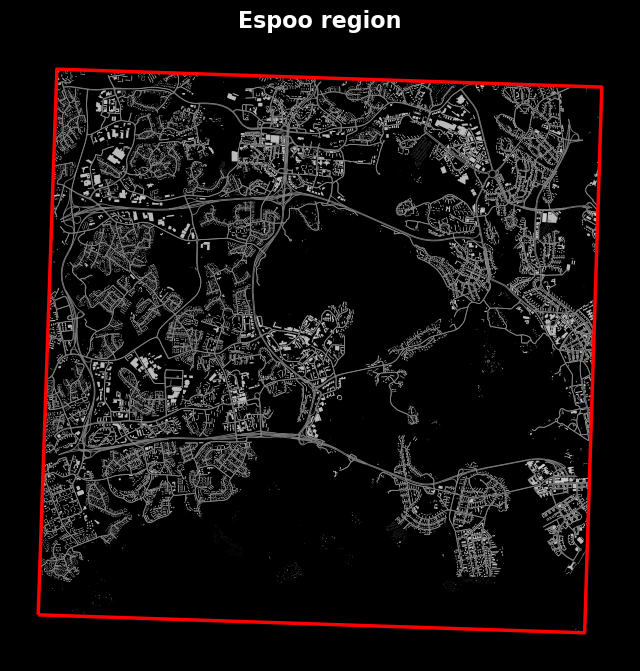

In [35]:
#plotting map of espoo
import matplotlib.pyplot as plt

# --- 0) Make sure everything is in EPSG:3067 (you already have _3067 layers) ---
# postal_area_3067, city_area_3067, roads_3067, poly_buildings  (all in 3067)

# --- 1) Geometry for clipping (postal polygon) ---
postal_geom = postal_area_3067.geometry.iloc[0]

# Clip roads + buildings to postal boundary (so nothing outside shows)
roads_clip = roads_3067.clip(postal_geom)
bldg_clip  = poly_buildings.clip(postal_geom)

# --- 2) Plot style like your example ---
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(8, 10))  # tall figure like screenshot

# Make background fully black
ax.set_facecolor("black")
fig.patch.set_facecolor("black")

# Buildings (light gray)
bldg_clip.plot(
    ax=ax,
    color="#CFCFCF",         # light gray
    edgecolor="none",
    alpha=0.90,
    zorder=2
)

# Roads (thin gray)
roads_clip.plot(
    ax=ax,
    color="#8A8A8A",         # mid gray
    linewidth=0.6,
    alpha=0.90,
    zorder=3
)

# Postal boundary (thick red)
postal_area_3067.boundary.plot(
    ax=ax,
    linewidth=2.5,
    color="red",
    alpha=1.0,
    zorder=4
)

# --- 3) Zoom to postal area bounds with small padding ---
minx, miny, maxx, maxy = postal_area_3067.total_bounds
pad_x = (maxx - minx) * 0.05
pad_y = (maxy - miny) * 0.05
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

# --- 4) Title + clean axes ---
ax.set_title("Espoo region", fontsize=16, weight="bold", pad=10)
ax.set_aspect("equal")
ax.set_axis_off()

plt.show()

## Problem 2 

Based on the buildings and district GeoDataFrames, calculate the building density for the given district. To do this, you should:

 - Calculate the total area of all buildings within your district
   - Note: Use the buildings and district from Problem 1
 - Divide this total building area by the area of the district
   - the result shows the building density as percentage (i.e. proportion of the land that is allocated for buildings)
 - Print the result for your district to the screen in percentages with 1 decimal point. I.e. it should say something like:
   - "Building density in Ullanlinna is 14.5 %. 

Please write your solution to the cell below (remove the `raise NotImplementedError()` code). You can create new cells as well if needed.

In [37]:
#Problem 3: Calculate building densities for Helsinki districts
import geopandas as gpd

# -------------------------------------------------
# Problem 2: Building density (robust + error-safe)
# -------------------------------------------------

# STEP 1: District geometry
district_geom = postal_area_3067.geometry.iloc[0]

# STEP 2: Ensure same CRS
if poly_buildings.crs != postal_area_3067.crs:
    poly_buildings = poly_buildings.to_crs(postal_area_3067.crs)

# STEP 3: Remove null geometries (safety)
poly_buildings = poly_buildings[poly_buildings.geometry.notna()].copy()

# STEP 4: Fix invalid geometries (common cause of intersection errors)
# buffer(0) is a standard quick fix for many polygon validity issues
poly_buildings["geometry"] = poly_buildings.geometry.buffer(0)
district_geom = district_geom.buffer(0)

# STEP 5: Select buildings that intersect district (fast filter)
buildings_in_district = poly_buildings[poly_buildings.intersects(district_geom)].copy()

# STEP 6: Clip by intersection (only keep part inside)
# Use apply to avoid vectorized GEOS errors in some environments
buildings_in_district["geometry"] = buildings_in_district.geometry.apply(
    lambda geom: geom.intersection(district_geom) if geom is not None else None
)

# Remove empty/invalid results
buildings_in_district = buildings_in_district[
    buildings_in_district.geometry.notna() & ~buildings_in_district.is_empty
].copy()

# STEP 7: Areas (m²) and density (%)
total_building_area = buildings_in_district.geometry.area.sum()
district_area = district_geom.area

building_density = (total_building_area / district_area) * 100

# STEP 8: Print (1 decimal)
print(f"Building density in {POSTAL_CODE} is {building_density:.1f} %.")



Building density in 02150 is 7.9 %.


## Problem 3 (3 points)

In this problem, your task is to calculate building densities for all districts in Helsinki. The end result should like something like following:

![Building densities](img/building-densities-Helsinki.png)

It is possible to extract city districts directly from OpenStreetMap (OSM). In OSM, different administrative levels are tagged with `admin_level` tag (see [OSM docs](https://wiki.openstreetmap.org/wiki/Tag:boundary%3Dadministrative#admin_level)) as well as the [Python tutorial 1](https://sustainability-gis.readthedocs.io/en/latest/tutorials/intro-to-python-geostack.html#example-select-buildings-for-specific-administrative-area). These admin levels are used in order to render different borders consistently among countries. E.g `admin_level="10"` is typically used to render districts, neighborhoods and so on, whereas `admin_level="4"` is typically used to draw provinces, regions, federal states etc. These values are country specific, hence, if you work in other countries please take a look at the country specific table from the [OSM docs](https://wiki.openstreetmap.org/wiki/Tag:boundary%3Dadministrative#admin_level). In many countries, `admin_level="10"` is used for neighborhoods, hence you can take advantage of that information and extract all the neighborhoods in the study area.

**Description**:

1. Read city districts into a variable called `city_districts` for Helsinki using `osmnx`, i.e. all rows in which the `"admin_level"` is `"10"` (see Tutorial 1).
2. Select only rows in which the `element_type` is `"relation"`
    - Hint: You can filter specific element types from the GeoDataFrame returned by `osmnx` by modifying the following command: `city_districts.loc["SPECIFY ELEMENT TYPE HERE"]`

3. Read buildings into a variable called `buildings` for Helsinki using `osmnx`.
4. Reproject the city districts and buildings into EPSG 3067 (i.e. into a metric system)
5. Create a new column called `density` for city districts GeoDataFrame and assign a value `0.0` to it
6. Iterate over city districts one by one using the `.iterrows()` method of pandas (see further info [here](https://python-gis-book.readthedocs.io/en/latest/part1/chapter-03/nb/02-data-analysis.html#using-a-function-by-iterating-over-rows) and [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iterrows.html)), AND:
    1. By default when iterating over the rows, a single row (i.e. district") is always presented as a `GeoSeries`. We need to convert this into a GeoDataFrame, so that we can do the following steps. Hence, convert the row representing a single `district` into a GeoDataFrame like this (modify if needed): `district = gpd.GeoDataFrame(district.to_frame().T, crs="epsg:3067")` 
    2. Select all buildings that are intersecting with a given district using spatial join: `gpd.sjoin()`
    3. Calculate the building density based on the area of buildings and the area of the district (in a similar manner as in Problem 2). 
    4. Update the result into the `density` column in the city districts GeoDataFrame. The density should be represented as a percentage (0-100) rounding it to 1 decimal.
6. Visualize the results and add a legend and title for the map as shown in the figure above.


Please write your solution to the cell below (remove the `raise NotImplementedError()` code). You can create new cells as well if needed.

In [7]:
# ============================================================
# STEP 0: Import libraries
# - osmnx: download OSM data (boundaries, buildings, districts)
# - geopandas: spatial tables and operations (join, clip, plot)
# - pandas: helps handle MultiIndex + filtering
# - matplotlib: plotting
# ============================================================
import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


In [8]:
# ============================================================
# STEP 1: OSMnx settings + define study area and CRS
# ============================================================
ox.settings.use_cache = True
ox.settings.log_console = False
ox.settings.timeout = 180

query = "Helsinki, Finland"
CRS_FIN = "EPSG:3067"

print("Settings configured for Helsinki.")


Settings configured for Helsinki.


In [9]:
# ============================================================
# STEP 2: Download Helsinki boundary polygon (study area)
# ============================================================
hel_gdf = ox.geocode_to_gdf(query)   # WGS84
hel_poly = hel_gdf.geometry.iloc[0]  # shapely polygon

print("Helsinki boundary downloaded.")
print("Boundary CRS:", hel_gdf.crs)


Helsinki boundary downloaded.
Boundary CRS: epsg:4326


In [10]:
# ============================================================
# STEP 3: Download city districts inside Helsinki (admin_level=10)
# ============================================================
district_tags = {"boundary": "administrative", "admin_level": "10"}
districts_all = ox.features_from_polygon(hel_poly, tags=district_tags)

print("districts_all rows:", len(districts_all))


districts_all rows: 751


In [11]:
# ============================================================
# STEP 4: Keep ONLY relations (required by assignment)
# ============================================================
if isinstance(districts_all.index, pd.MultiIndex):
    city_districts = districts_all.loc["relation"].copy()
else:
    city_districts = districts_all[districts_all["element_type"] == "relation"].copy()

print("Relation districts:", len(city_districts))


Relation districts: 231


In [13]:
# ============================================================
# STEP 5: Keep only polygon geometries
# ============================================================
city_districts = city_districts[
    city_districts.geometry.type.isin(["Polygon", "MultiPolygon"])
].copy()

print("city_districts (relations + polygons):", len(city_districts))


city_districts (relations + polygons): 231


In [14]:
# ============================================================
# STEP 6: Download buildings inside Helsinki
# ============================================================
buildings_all = ox.features_from_polygon(
    hel_poly,
    tags={"building": True}
)

print("All building features:", len(buildings_all))


All building features: 66771


In [15]:
# ============================================================
# STEP 7: Keep valid building geometries
# ============================================================
buildings = buildings_all[
    buildings_all.geometry.type.isin(["Polygon", "MultiPolygon"])
].copy()

buildings = buildings[buildings.geometry.notna()].copy()

print("buildings (polygons):", len(buildings))


buildings (polygons): 66646


In [16]:
# ============================================================
# STEP 8: Reproject layers to EPSG:3067
# ============================================================
city_districts = city_districts.to_crs(CRS_FIN)
buildings = buildings.to_crs(CRS_FIN)
hel_3067 = hel_gdf.to_crs(CRS_FIN)

print("Reprojection completed.")


Reprojection completed.


In [17]:
# ============================================================
# STEP 9: Fix invalid geometries
# ============================================================
city_districts["geometry"] = city_districts.geometry.buffer(0)
buildings["geometry"] = buildings.geometry.buffer(0)

print("Geometry repair applied.")


Geometry repair applied.


In [18]:
# ============================================================
# STEP 10: Remove unrealistically large districts
# ============================================================
hel_area = float(hel_3067.geometry.iloc[0].area)
city_districts["d_area"] = city_districts.geometry.area

city_districts = city_districts[
    city_districts["d_area"] <= hel_area * 1.05
].copy()

print("Remaining districts:", len(city_districts))


Remaining districts: 227


In [19]:
# ============================================================
# STEP 11: Prepare density calculation
# ============================================================
city_districts["density"] = 0.0
buildings["b_area"] = buildings.geometry.area

print("Density column initialized.")


Density column initialized.


In [20]:
# ============================================================
# STEP 12: Compute density district-by-district
# ============================================================
for idx, district in city_districts.iterrows():

    district_gdf = gpd.GeoDataFrame(district.to_frame().T, crs=CRS_FIN)
    district_geom = district_gdf.geometry.iloc[0]

    b_in = gpd.sjoin(
        buildings,
        district_gdf[["geometry"]],
        how="inner",
        predicate="intersects"
    )

    if len(b_in) > 0:
        b_in = b_in.copy()
        b_in["geometry"] = b_in.geometry.intersection(district_geom)
        b_in = b_in[b_in.geometry.notna() & ~b_in.is_empty]
        total_building_area = b_in.geometry.area.sum()
    else:
        total_building_area = 0.0

    district_area = float(district_geom.area)
    dens = (total_building_area / district_area) * 100 if district_area > 0 else 0.0
    city_districts.at[idx, "density"] = round(dens, 1)

print("✅ Density computed.")


✅ Density computed.


In [22]:
# impact density
city_districts["density"].describe()


count    227.000000
mean       8.369163
std        7.809361
min        0.000000
25%        0.500000
50%        8.300000
75%       12.850000
max       41.100000
Name: density, dtype: float64

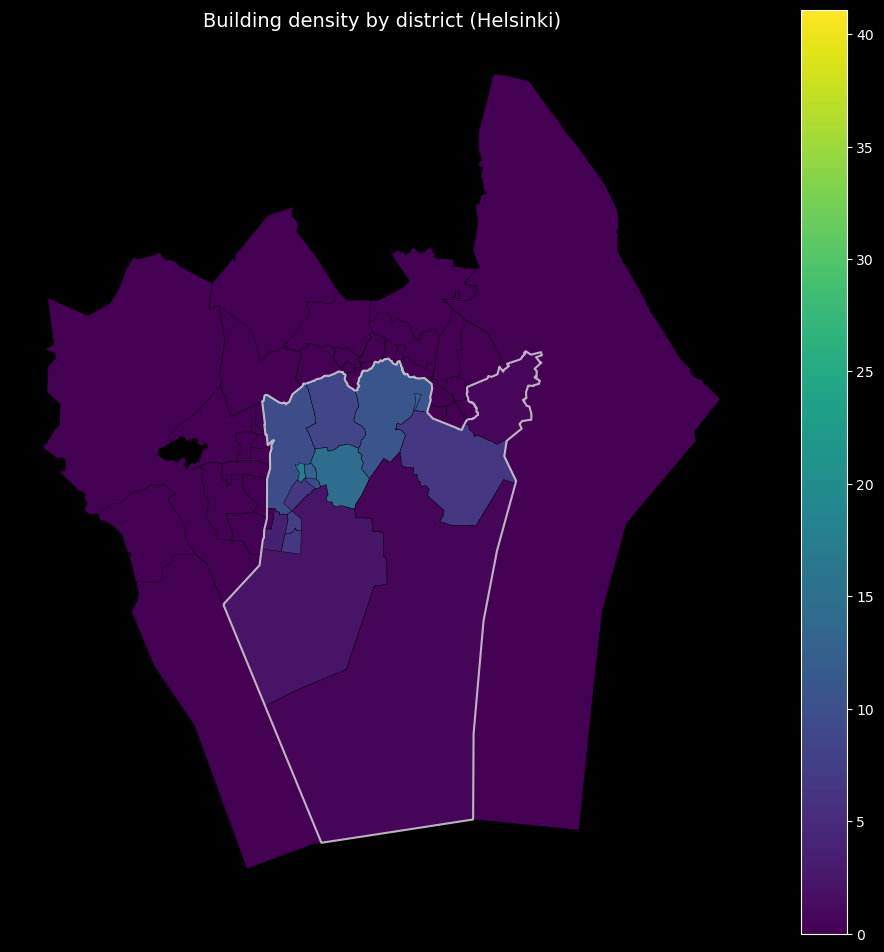

In [23]:
# ============================================================
# STEP 14: Plot density choropleth map
# ============================================================
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(12, 12))

hel_3067.boundary.plot(
    ax=ax,
    linewidth=1.5,
    color="white",
    alpha=0.7
)

city_districts.plot(
    ax=ax,
    column="density",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.3
)

ax.set_title(
    "Building density by district (Helsinki)",
    fontsize=14
)
ax.set_axis_off()
plt.show()
